# Postprocessing Variant Analysis

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

import gzip
import statistics

this is the evaluation notebook used in my report, however, files can not be provided due to data privacy

## Get Variants to Samples Distribution

In [ ]:
def count_patient_samples(samples):
    if not isinstance(samples, str):
        return 0

    samples = samples.split(",")

    return sum(
        1 for sample in samples
        if "pa" in sample.strip().lower()
    )

In [ ]:
def plot_patient_variant_sample_distribution(all_sv_df):

    distribution = (
        all_sv_df["N_PATIENTS"]
        .value_counts()
        .sort_index()
    )

    # Remove variants that occur in zero patients
    distribution = distribution[distribution.index > 0]

    # Figure
    plt.style.use("ggplot")
    if max(all_sv_df["N_PATIENTS"].unique()) > 30:
        plt.figure(figsize=(10, 5))
    else:
        plt.figure(figsize=(8, 5))

    ax = distribution.plot(
        kind="bar",
        edgecolor="black",
        color="#4C78A8"
    )

    plt.xlabel("Number of patients carrying variant", fontsize=14)
    plt.ylabel("Number of variants", fontsize=14)

    # Keep x-axis labels horizontal
    plt.xticks(rotation=0, fontsize=12)
    plt.yticks(fontsize=12)

    # Maximum bar height
    max_height = distribution.max()

    # Add counts above bars
    for i, patch in enumerate(ax.patches):

        height = patch.get_height()

        if height > 0:

            x = patch.get_x() + patch.get_width() / 2

            # Bars 2–7: stagger labels and connect them to bars
            if 1 <= i <= 5:

                label_offsets = [
                    0.24,  # bar 2
                    0.16,  # bar 3
                    0.24,  # bar 4
                    0.16,  # bar 5
                    0.08,  # bar 6
                    #0.24   # bar 7
                ]

                label_y = height + max_height * label_offsets[i - 1]

                ax.annotate(
                    f"{int(height)}",
                    xy=(x, height),
                    xytext=(x, label_y),
                    ha="left",
                    va="bottom",
                    fontsize=12,
                    arrowprops=dict(
                        arrowstyle="-",
                        color="black",
                        lw=1
                    )
                )

            # All other bars: label directly above the bar
            else:
                ax.text(
                    x,
                    height,
                    f"{int(height)}",
                    ha="left",
                    va="bottom",
                    fontsize=12
                )

    # Total number of variants
    ax.text(
        0.98,
        0.95,
        f"Total variants: {all_sv_df.shape[0]}",
        transform=ax.transAxes,
        ha="right",
        va="top",
        fontsize=14,
        bbox=dict(
            boxstyle="round,pad=0.3",
            facecolor="white",
            edgecolor="black"
        )
    )

    plt.tight_layout()
    plt.show()

### Across all Filtered Variants

In [13]:
SV_COL=[
    "CHROM", 
    "AVG_START",
    "AVG_END", 
    "GT", 
    "ID",
    "SVTYPE",
    "AVG_LEN", 
    "SAMPLES_HET",
    "SAMPLES_HOM", 
    "CNV_SUPP"
]
all_sv_df = pd.read_csv("/archive/emedgene_data/variant_analysis/output_final/cnv_support/filtered_sv.bed", sep="\t", header=None, names=SV_COL)

This file contains all structural variants across our cohort appearing not frequently in gnomAD and our inhouse data.

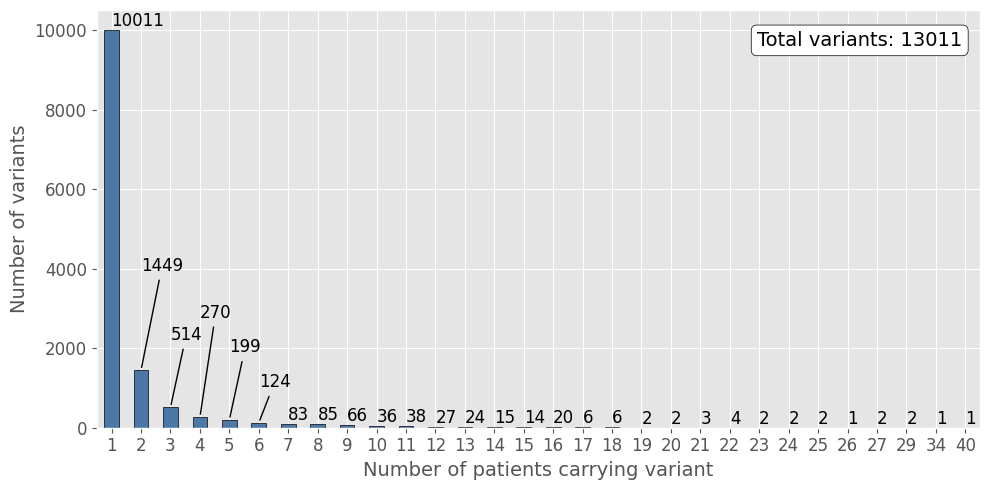

In [ ]:
key =[
    "CHROM", 
    "AVG_START",
    "AVG_END", 
    "GT", 
    "ID",
    "SAMPLES_HET",
    "SAMPLES_HOM"
]

subset = all_sv_df[key].drop_duplicates()
subset["N_PATIENT_HET"] = subset["SAMPLES_HET"].apply(count_patient_samples)
subset["N_PATIENT_HOM"] = subset["SAMPLES_HOM"].apply(count_patient_samples)

subset["N_PATIENTS"] = (
    subset["N_PATIENT_HET"] +
    subset["N_PATIENT_HOM"]
)

plot_patient_variant_sample_distribution(subset)

/tmp/ipykernel_1542615/2818409923.py:87: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0.06, 0, 1, 1])


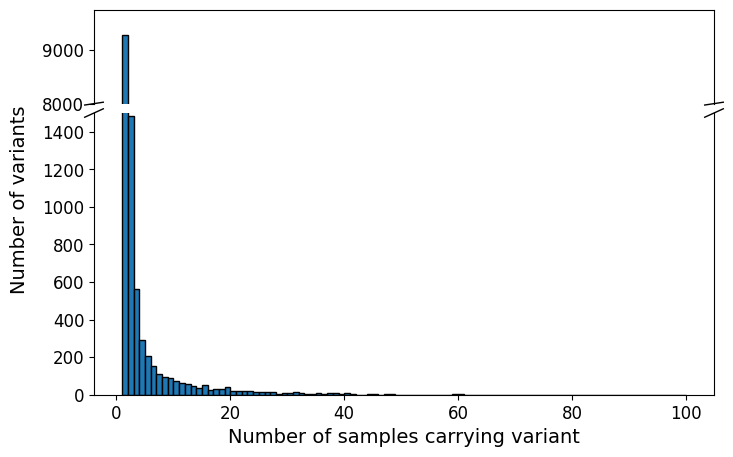

In [ ]:
# @title `broken axis`
def variant_sample_distribution_broken_axis():
    fig, (ax1, ax2) = plt.subplots(
        2, 1,
        sharex=True,
        figsize=(8, 5),
        gridspec_kw={"height_ratios": [1, 3], "hspace": 0.05}
    )

    bins = range(1, all_sv_df["N_SAMPLES"].max() + 2)

    # Upper part
    all_sv_df["N_SAMPLES"].plot(
        kind="hist",
        bins=bins,
        edgecolor="black",
        ax=ax1
    )

    # Lower part
    all_sv_df["N_SAMPLES"].plot(
        kind="hist",
        bins=bins,
        edgecolor="black",
        ax=ax2
    )

    # Skip 3500–8000
    ax1.set_ylim(8000, None)
    ax2.set_ylim(0, 1500)

    # Remove the spines where the break occurs
    ax1.spines["bottom"].set_visible(False)
    ax2.spines["top"].set_visible(False)

    ax1.tick_params(axis="x", bottom=False, labelbottom=False)

    # Diagonal break marks
    d = 0.015

    kwargs = dict(
        color="black",
        clip_on=False,
        linewidth=1
    )

    ax1.plot((-d, d), (-d, d), transform=ax1.transAxes, **kwargs)
    ax1.plot((1-d, 1+d), (-d, d), transform=ax1.transAxes, **kwargs)

    ax2.plot((-d, d), (1-d, 1+d), transform=ax2.transAxes, **kwargs)
    ax2.plot((1-d, 1+d), (1-d, 1+d), transform=ax2.transAxes, **kwargs)

    # Labels
    ax2.set_xlabel("Number of samples carrying variant", fontsize=14)

    # Remove individual y-axis labels
    ax1.set_ylabel("")
    ax2.set_ylabel("")

    # One shared y-axis label
    fig.text(
        0.02, 0.5,
        "Number of variants",
        va="center",
        rotation="vertical",
        fontsize=14
    )

    # Tick sizes
    ax1.tick_params(axis="y", labelsize=12)
    ax2.tick_params(axis="y", labelsize=12)
    ax2.tick_params(axis="x", labelsize=12)

    plt.tight_layout(rect=[0.06, 0, 1, 1])
    plt.show()

variant_sample_distribution_broken_axis()

It is clearly observable that most variants appear only in one sample.
Most of them are likely benign variants found in individuals making up the differences in the genetic code or might actually just be artifacts.
The goal is to find the variants causing neutropenia. These variants can of course be patient specific but might also be found across mutiple samples explaining the disease.

### Across all Filtered Variants within gene annotated cCREs

In [59]:
all_sv_df = pd.read_csv("/archive/emedgene_data/variant_analysis/output_original/prioritized/prioritized_filtered_sv.tsv", sep="\t")
all_sv_df = all_sv_df[["CHROM","AVG_START","AVG_END","GT","ID","SVTYPE","AVG_LEN","SAMPLES_HET","SAMPLES_HOM"]].drop_duplicates()

In [41]:
all_sv_df.shape

(1608, 15)

In [ ]:
all_sv_df["N_PATIENT_HET"] = all_sv_df["SAMPLES_HET"].apply(count_patient_samples)
all_sv_df["N_PATIENT_HOM"] = all_sv_df["SAMPLES_HOM"].apply(count_patient_samples)

all_sv_df["N_PATIENTS"] = (
    all_sv_df["N_PATIENT_HET"] +
    all_sv_df["N_PATIENT_HOM"]
)

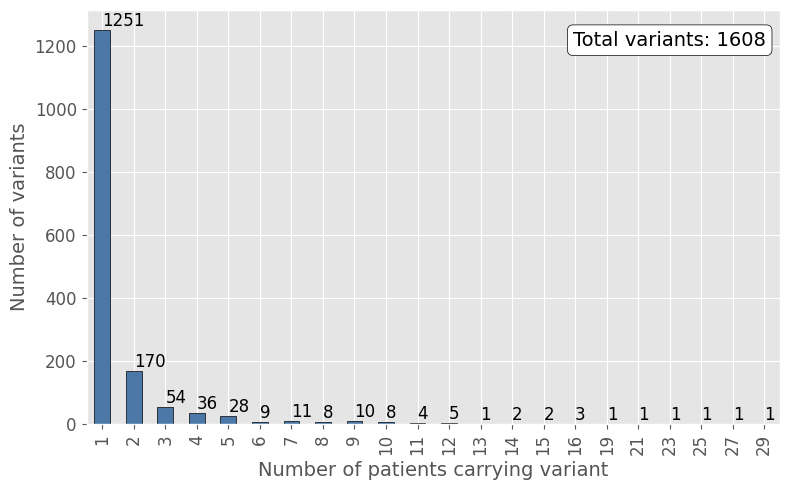

In [70]:
plot_patient_variant_sample_distribution(all_sv_df)

## Analyzing Prioritized Output Per Panel Input

All prioritized full data have the same variants but different panel genes annotated as support.

In [2]:
prioritized_datafiles = {
    "HPO":"/archive/emedgene_data/variant_analysis/output/prioritized/prioritized_filtered_sv_hpo.tsv",
    "Nedrex_Diamond":"/archive/emedgene_data/variant_analysis/output/prioritized/prioritized_filtered_sv_nedrex_diamond.tsv",
    "Nedrex_Domino":"/archive/emedgene_data/variant_analysis/output/prioritized/prioritized_filtered_sv_nedrex_domino.tsv",
    "String_Diamond":"/archive/emedgene_data/variant_analysis/output/prioritized/prioritized_filtered_sv_string_diamond.tsv",
    "String_Domino":"/archive/emedgene_data/variant_analysis/output/prioritized/prioritized_filtered_sv_string_domino.tsv",
}

In [104]:
###### MERGE ALL PANEL OUTPUTS
def load_file(file):
    return pd.read_csv(file, sep="\t")

# load default df with panel genes
default_df = load_file("/archive/emedgene_data/variant_analysis/output/prioritized/prioritized_filtered_sv.tsv")

prioritized_df = {}

for key, value in prioritized_datafiles.items():
    df = load_file(value)
    prioritized_df[key] = df
    default_df = default_df.merge(df[["CHROM","AVG_START","AVG_END","GT","PANEL_SUPP"]],
                    on=["CHROM","AVG_START","AVG_END","GT"],
                    how="left"
                ).rename(columns={
                    "PANEL_SUPP_x": "PANEL_SUPP",
                    "PANEL_SUPP_y": f"PANEL_SUPP_{key}"
                })

col = "PANEL_SUPP"

default_df = default_df[
    [c for c in default_df.columns if c != col] + [col]
]

default_df.head()

,CHROM,AVG_START,AVG_END,GT,ID,SVTYPE,AVG_LEN,SAMPLES_HET,SAMPLES_HOM,CNV_SUPP,...,cCRE_ID,cCRE_CLASS,GENE_NAME,GENE_ID,PANEL_SUPP_HPO,PANEL_SUPP_Nedrex_Diamond,PANEL_SUPP_Nedrex_Domino,PANEL_SUPP_String_Diamond,PANEL_SUPP_String_Domino,PANEL_SUPP
0,chr6,43687666,43687667,0/1,27_DRAGEN:INS:69835:0:0:0:5:0,INS,0,"SCN590pa,SCN393pa,SCN54pa_si,SCN450pa,SCN423pa",NaN,False,...,EH38E3709230,PLS,"ENSG00000218107,ENSG00000271754,ENSG0000027211...","ENSG00000112715,ENSG00000124688,ENSG0000017243...",[],[],[],[],[],[]
1,chr13,113364226,113364227,0/1,17_DRAGEN:DUP:TANDEM:332:1486:1486:0:2:0,INS,192,"SCN497pa,SCN590pa,SCN393pa,SCN54pa",NaN,False,...,EH38E3083826,PLS,"CUL4A,ENSG00000283828,LAMP1,PCID2,PROZ,TFDP1","ENSG00000185896,ENSG00000126231,ENSG0000028382...",[],[],['LAMP1'],[],[],[]
2,chr11,119030752,119033932,1/1,12_DRAGEN:DEL:146409:0:1:0:0:0,DEL,3179,"SCN393si,SCN393fa,SCN393mo","SCN445pa,SCN393pa,SCN393pa_si",False,...,"EH38E1574693,EH38E1574694,EH38E1574695,EH38E29...","Low-DNase,PLS,pELS","ARCN1,CBL,CCDC153,CENATAC,CENATAC-DT,DDX6,DPAG...","ENSG00000149428,ENSG00000076706,ENSG0000011818...",[],['H2AX'],[],['H2AX'],[],"['HYOU1', 'SLC37A4']"
3,chr1,2019219,2019220,1/1,56_DRAGEN:INS:88:13:13:0:1:0,INS,230,NaN,"SCN393pa,SCN54pa_si",False,...,EH38E2778195,PLS,CFAP74,ENSG00000142609,[],[],[],[],[],[]
4,chr1,109656603,109656614,0/1,56_DRAGEN:INS:6918:0:0:0:15:0,INS,0,"SCN393pa,SCN54pa",NaN,False,...,EH38E3976041,PLS,"AHCYL1,ATXN7L2,CSF1,ENSG00000228703,ENSG000002...","ENSG00000134202,ENSG00000213366,ENSG0000006513...",[],[],[],[],[],[]


In [105]:
panel_cols = [c for c in default_df.columns if c.startswith("PANEL_SUPP")]

panel_df = default_df[
    default_df[panel_cols].ne("[]").any(axis=1)
]
panel_df.head()

,CHROM,AVG_START,AVG_END,GT,ID,SVTYPE,AVG_LEN,SAMPLES_HET,SAMPLES_HOM,CNV_SUPP,...,cCRE_ID,cCRE_CLASS,GENE_NAME,GENE_ID,PANEL_SUPP_HPO,PANEL_SUPP_Nedrex_Diamond,PANEL_SUPP_Nedrex_Domino,PANEL_SUPP_String_Diamond,PANEL_SUPP_String_Domino,PANEL_SUPP
1,chr13,113364226,113364227,0/1,17_DRAGEN:DUP:TANDEM:332:1486:1486:0:2:0,INS,192,"SCN497pa,SCN590pa,SCN393pa,SCN54pa",NaN,False,...,EH38E3083826,PLS,"CUL4A,ENSG00000283828,LAMP1,PCID2,PROZ,TFDP1","ENSG00000185896,ENSG00000126231,ENSG0000028382...",[],[],['LAMP1'],[],[],[]
2,chr11,119030752,119033932,1/1,12_DRAGEN:DEL:146409:0:1:0:0:0,DEL,3179,"SCN393si,SCN393fa,SCN393mo","SCN445pa,SCN393pa,SCN393pa_si",False,...,"EH38E1574693,EH38E1574694,EH38E1574695,EH38E29...","Low-DNase,PLS,pELS","ARCN1,CBL,CCDC153,CENATAC,CENATAC-DT,DDX6,DPAG...","ENSG00000149428,ENSG00000076706,ENSG0000011818...",[],['H2AX'],[],['H2AX'],[],"['HYOU1', 'SLC37A4']"
5,chr11,65540705,65540706,1/1,3_DRAGEN:INS:90617:0:0:0:0:0,INS,59,"SCN487si,SCN344mo,SCN344fa,SCN613fa,SCN379br","SCN344pa,SCN423pa",False,...,EH38E2964508,PLS,"CFL1,DPF2,EHBP1L1,ENSG00000254501,ENSG00000254...","ENSG00000142186,ENSG00000173465,ENSG0000017697...",[],[],[],['DPF2'],['CFL1'],[]
7,chr4,143184854,143184856,1/1,98_DRAGEN:INS:120:706:706:0:0:0,INS,57,NaN,"SCN110pa3,SCN110pa2",False,...,EH38E2331991,PLS,"ABCE1,ANAPC10,ELF2,ELMOD2,ENSG00000228981,ENSG...","ENSG00000109458,ENSG00000153147,ENSG0000024511...","['MMAA,LRBA']",[],[],['SMARCA5'],[],[]
9,chr19,2040627,2050639,0/1,4_DRAGEN:DEL:154371:0:1:0:0:0,DEL,10011,SCN487pa,NaN,True,...,"EH38E3281801,EH38E3281802,EH38E3281803,EH38E32...","PLS,dELS,pELS","ABHD17A,AP3D1,ATP5F1D,BTBD2,CIRBP,CIRBP-AS1,CS...","ENSG00000065000,ENSG00000099622,ENSG0000009987...",[],[],[],['DOT1L'],[],['AP3D1']


In [106]:
panel_df.shape

(16019, 23)

In [107]:
#panel_df = panel_df.fillna("")
panel_df = panel_df.drop_duplicates()
panel_df.shape

(151, 23)

In [ ]:
panel_df.to_csv("/archive/emedgene_data/variant_analysis/output_final/postprocessing/panel_involved_variants.tsv", sep="\t", index=False)

## Filter Out Unrealistic Inheritance Patterns

In [ ]:
def filter_inheritance(panel_df, inheritance_data, out):
    filter_out = [
        "De novo candidate (hom) (trio analysis)", # highly unlikely in mendelian scenario
    ]

    inheritance_lookup = (
        inheritance_data
        .set_index(["CHR", "AVG_START", "AVG_END", "VARIANTid", "PATIENT"])["INHERITANCE"]
        .to_dict()
    )

    def filter_samples(row):
        variant_key = (
            row["CHROM"],
            row["AVG_START"]+1,
            row["AVG_END"],
            row["ID"],
        )

        samples = row["SAMPLES_HOM"]

        # Handle NaN / empty values
        if pd.isna(samples):
            return samples

        samples = samples.split(",")

        filtered_samples = [
            sample
            for sample in samples
            if inheritance_lookup.get((*variant_key, sample)) not in filter_out
        ]

        samples_hom = ",".join(filtered_samples)

        return samples_hom

    panel_df["SAMPLES_HOM"] = panel_df.apply(filter_samples, axis=1)

    # remove missing calls
    panel_df["SAMPLES_HET"] = panel_df["SAMPLES_HET"].replace("", pd.NA)
    panel_df["SAMPLES_HOM"] = panel_df["SAMPLES_HOM"].replace("", pd.NA)
    panel_df = panel_df.dropna(
        subset=["SAMPLES_HET", "SAMPLES_HOM"],
        how="all"
    )

    panel_df = panel_df = panel_df[
        ~(
            (panel_df["GT"] == "1/1") &
            (panel_df["SAMPLES_HOM"].isna())
        )
    ]

    panel_df.to_csv(out, sep="\t", index=False)

In [ ]:
panel_df_copy = panel_df.copy()

In [ ]:
# load inheritance data
inheritance_data = pd.read_csv("/archive/emedgene_data/variant_analysis/output/inheritance/inheritance_affected.tsv", sep="\t",)


In [ ]:
filter_inheritance(panel_df, inheritance_data, "/archive/emedgene_data/variant_analysis/output/postprocessing/panel_involved_variants_inheritance_filtered.tsv")

## Variant Count Overview during Filtering

In [3]:
def get_count_vcf(data_dir_path, file_path, description):
    print(description)
    data_dir = Path(data_dir_path)

    results = []

    for vcf_file in data_dir.glob(file_path):

        n_variants = 0
        if file_path.endswith(".gz"):
            sample = vcf_file.parent.name
            with gzip.open(vcf_file, "rt") as f:
                for line in f:
                    if not line.startswith("#"):
                        n_variants += 1
        elif file_path.endswith(".vcf"):
            sample = "_".join(vcf_file.name.split("_")[:-1])
            with open(vcf_file, "r") as f:
                for line in f:
                    if not line.startswith("#"):
                        n_variants += 1
        else:
            print("Invalid file needs a .vcf or .vcf.gz. Abort...")
            return None, None, None

        group = "affected" if "pa" in sample.lower() else "healthy"

        results.append({
            "sample": sample,
            "variants": n_variants,
            "group": group,
        })

    return results

### Get Avg Variant Count across Cohort

In [20]:
results = get_count_vcf("/archive/emedgene_data/data", "*/*/*.dragen.sv.vcf.gz", "Variant Count Statistics for Cohort:")

# Calculate averages
all_avg = statistics.mean(r["variants"] for r in results)
all_std = statistics.stdev(r["variants"] for r in results)

affected = [r["variants"] for r in results if r["group"] == "affected"]
healthy = [r["variants"] for r in results if r["group"] == "healthy"]

affected_avg = statistics.mean(affected) if affected else 0
healthy_avg = statistics.mean(healthy) if healthy else 0

affected_std = statistics.stdev(affected) if affected else 0
healthy_std = statistics.stdev(healthy) if healthy else 0

print("\nSummary")
print(f"Number of samples:    {len(results)}")
print(f"Total variants:       {sum(r['variants'] for r in results):,}")
print(f"Total Affected:       {sum(affected):,}")
print(f"Total Healthy:       {sum(healthy):,}")
print(f"Range Affected: min={min(affected)}, max={max(affected)}")
print(f"Range Healthy:  min={min(healthy)}, max={max(healthy)}")
print(f"Average all samples:  {all_avg:.2f}")
print(f"Average affected:     {affected_avg:.2f} (n={len(affected)})")
print(f"Average healthy:      {healthy_avg:.2f} (n={len(healthy)})")
print(f"Std all:     {all_avg:.2f} ± {all_std:.2f}")
print(f"Std affected:     {affected_avg:.2f} ± {affected_std:.2f} (n={len(affected)})")
print(f"Std healthy:      {healthy_avg:.2f} ± {healthy_std:.2f} (n={len(healthy)})")

Variant Count Statistics for Cohort:

Summary
Number of samples:    137
Total variants:       2,232,863
Total Affected:       914,574
Total Healthy:       1,318,289
Range Affected: min=8931, max=21762
Range Healthy:  min=8643, max=21895
Average all samples:  16298.27
Average affected:     16331.68 (n=56)
Average healthy:      16275.17 (n=81)
Std all:     16298.27 ± 2717.19
Std affected:     16331.68 ± 2849.70 (n=56)
Std healthy:      16275.17 ± 2639.50 (n=81)


### Get Avg Variant Count across Cohort after QC Filtering

In [23]:
results_qc = get_count_vcf("/archive/emedgene_data/variant_analysis/output_final/sv_filtered", "*/*_filtered.vcf", "Variant Count Statistics for Cohort after QC Filtering:")
all_avg_qc = statistics.mean(r["variants"] for r in results_qc)
all_std_qc = statistics.stdev(r["variants"] for r in results_qc)

affected_qc = [r["variants"] for r in results_qc if r["group"] == "affected"]
healthy_qc = [r["variants"] for r in results_qc if r["group"] == "healthy"]

affected_avg_qc = statistics.mean(affected_qc) if affected_qc else 0
healthy_avg_qc = statistics.mean(healthy_qc) if healthy_qc else 0

affected_std_qc = statistics.stdev(affected_qc) if affected_qc else 0
healthy_std_qc = statistics.stdev(healthy_qc) if healthy_qc else 0

print("\nSummary")
print(f"Number of samples:    {len(results_qc)}")
print(f"Total variants:       {sum(r['variants'] for r in results_qc):,}")
print(f"Total Affected:       {sum(affected_qc):,}")
print(f"Total Healthy:       {sum(healthy_qc):,}")
print(f"Range Affected: min={min(affected_qc)}, max={max(affected_qc)}")
print(f"Range Healthy:  min={min(healthy_qc)}, max={max(healthy_qc)}")
print(f"Average all samples:  {all_avg_qc:.2f}")
print(f"Average affected:     {affected_avg_qc:.2f} (n={len(affected)})")
print(f"Average healthy:      {healthy_avg_qc:.2f} (n={len(healthy)})")
print(f"Std all:     {all_avg_qc:.2f} ± {all_std_qc:.2f}")
print(f"Std affected:     {affected_avg_qc:.2f} ± {affected_std_qc:.2f} (n={len(affected_qc)})")
print(f"Std healthy:      {healthy_avg_qc:.2f} ± {healthy_std_qc:.2f} (n={len(healthy_qc)})")

Variant Count Statistics for Cohort after QC Filtering:

Summary
Number of samples:    137
Total variants:       1,697,535
Total Affected:       691,601
Total Healthy:       1,005,934
Range Affected: min=6038, max=15551
Range Healthy:  min=6935, max=15813
Average all samples:  12390.77
Average affected:     12350.02 (n=56)
Average healthy:      12418.94 (n=81)
Std all:     12390.77 ± 2097.09
Std affected:     12350.02 ± 2238.43 (n=56)
Std healthy:      12418.94 ± 2007.37 (n=81)


### Get Number of Variants in Merged Call Set

In [4]:
# read jasmine output 

n_merged_variants = 0

with open("/archive/emedgene_data/variant_analysis/output_final/sv_jasmine/all_samples_jasmine.vcf", "r") as f:
                for line in f:
                    if not line.startswith("#"):
                        n_merged_variants += 1
                        
print(f"Number of variants in merged callset:      {n_merged_variants}")

Number of variants in merged callset:      100195


### Number of disease relevant variants after population frequency filtering

#### Get number of disease relevant variants after GT filtering within Cohort

In [5]:
# read gt filtering output
gt_df = pd.read_csv("/archive/emedgene_data/variant_analysis/output_final/sv_jasmine/affected_sv_gtFiltered.bed", sep="\t", header=None, names=["CHROM","AVG_START","AVG_END","GT","ID","SVTYPE","AVG_LEN","SAMPLES_HET","SAMPLES_HOM"])

gt_variants = gt_df["ID"].nunique()
print(f"Number of variants after Cohort filtering: {gt_variants}")

Number of variants after Cohort filtering: 17693


#### Get number of disease relevant variants after GT filtering within inhouse

In [6]:
# read all inhouse variants to be removed
inhouse_df = pd.read_csv("/archive/emedgene_data/variant_analysis/output_final/population_freq_filtered/jasmine_inhouse_overlap_70perc.bed",  sep="\t", header=None, names=["CHROM","AVG_START","AVG_END","GT","ID","SVTYPE","AVG_LEN","SAMPLES_HET","SAMPLES_HOM", "CHROM_i","START_i","END_i","SVTYPE_i","Het","Hom","TEN","AF"])

inhouse_overlap = inhouse_df["ID"].nunique()
total_inhouse = gt_variants - inhouse_overlap
print(f"Number of variants to remove: {inhouse_overlap}")
print(f"Total of variants after in-house filtering: {total_inhouse}")

Number of variants to remove: 4027
Total of variants after in-house filtering: 13666


In [7]:
# read all inhouse variants to be removed
gnomad_df = pd.read_csv("/archive/emedgene_data/variant_analysis/output_final/population_freq_filtered/jasmine_gnomad_overlap_70perc.bed", sep="\t", header=None, names=["CHROM","AVG_START","AVG_END","GT","ID","SVTYPE","AVG_LEN","SAMPLES_HET","SAMPLES_HOM", "CHROM_g", "START_g","END_g","ID_g","SVTYPE_g","AF", "FREQ_HOMALT", "FREQ_HET"])
print(gnomad_df.shape)
keys = ['CHROM', 'AVG_START', 'AVG_END', 'GT',"ID"]

gnomad_df = (
    gnomad_df.loc[gnomad_df['AF'] > 0.001, keys]
    .drop_duplicates()
)
gnomad_overlap = gnomad_df["ID"].nunique()

# IDs removed by in-house filtering
inhouse_ids = set(inhouse_df["ID"].dropna().unique())

# IDs removed by gnomAD filtering
gnomad_ids = set(gnomad_df["ID"].dropna().unique())

# Variants that would be removed by gnomAD
# but were ALREADY removed by in-house filtering
overlap_ids = inhouse_ids & gnomad_ids

# Only gnomAD variants that are still present after in-house filtering
gnomad_remaining_ids = gnomad_ids - inhouse_ids


total_gnomad = total_inhouse - len(gnomad_remaining_ids)

print(f"Number of variants to remove: {len(gnomad_remaining_ids)}")
print(f"Total of variants after filtering: {total_gnomad}")

(4034, 17)
Number of variants to remove: 655
Total of variants after filtering: 13011


### Plot overview

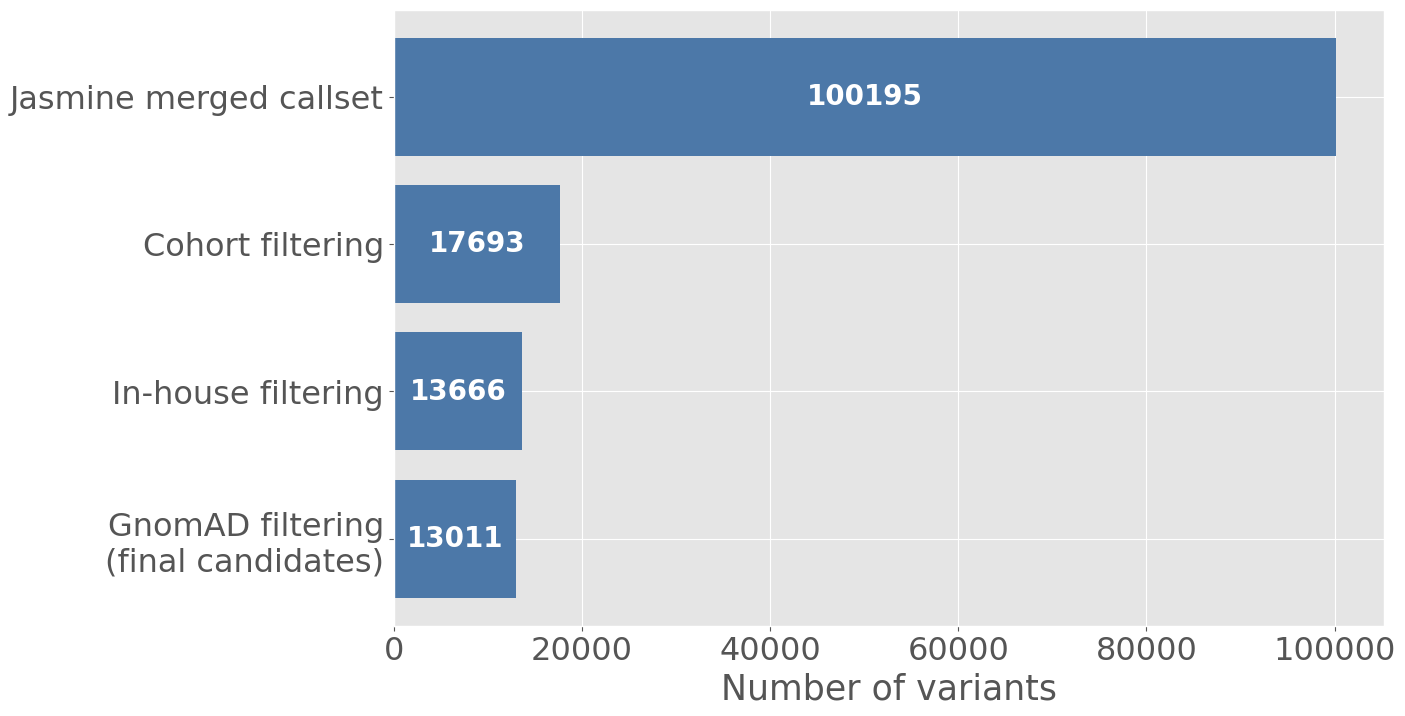

In [8]:
steps = [
    #"Avg. initial variants\nper individual",
    #"QC filtering",
    "Jasmine merged callset",
    "Cohort filtering",
    "In-house filtering",
    "GnomAD filtering\n(final candidates)",
]

counts = [
    #int(all_avg),
    #int(all_avg_qc),
    n_merged_variants,
    gt_variants,
    total_inhouse,
    total_gnomad,
]

plt.style.use("ggplot")

fig, ax = plt.subplots(figsize=(18, 8))

ax.barh(steps[::-1], counts[::-1],color="#4C78A8")

# Axis labels
ax.set_xlabel("Number of variants", fontsize=25)

# Y-axis labels
ax.tick_params(axis="y", labelsize=23)

# X-axis tick labels
ax.tick_params(axis="x", labelsize=23)

# Variant count labels
for i, count in enumerate(counts[::-1]):
    ax.text(
        count / 2, i,
        f"{count}",
        va="center",
        ha="center",
        fontsize=20,
        fontweight="bold",
        color="white"
    )

plt.subplots_adjust(left=0.35)
plt.show()

In [9]:
(total_gnomad/n_merged_variants)

0.1298567792804032

## Variant Overview During Annotation

### Number of Variants in gene region

In [ ]:
bed_dir = Path("/archive/emedgene_data/variant_analysis/output_original/gene_region")

n_gene_region = {}

Region_COL = [
    "CHROM", "AVG_START", "AVG_END", "GT", "ID", "SVTYPE",
    "AVG_LEN", "SAMPLES_HET", "SAMPLES_HOM", "CNV_SUPP",
    "CHROM_gene", "START_g", "END_g", "GENE_NAME", "LABEL"
]

for bed_file in sorted(bed_dir.glob("*.bed")):
    df = pd.read_csv(bed_file, sep="\t", names = Region_COL)
    
    n_unique = df["ID"].nunique()

    approach = bed_file.name.replace("sv_in_gene_region", "").replace(".bed", "").lstrip("_")

    if approach == "":
        approach = "panel"

    n_gene_region[approach] = (n_unique, df["ID"].unique())
    
    print(f"{approach}: {n_unique} unique IDs")

panel: 16 unique IDs
hpo: 28 unique IDs
nedrex_diamond: 27 unique IDs
nedrex_domino: 2 unique IDs
string_diamond: 33 unique IDs
string_domino: 12 unique IDs


### Number of Variants within a cCREs

In [55]:
# count number of variants per ccres 
ccres_variants2 = pd.read_csv("/archive/emedgene_data/variant_analysis/output/screen_analysis/screen_merge_sv.tsv", sep="\t")
ccres_variants2["ID"].nunique()

1608

In [56]:
counts = (
    ccres_variants2.groupby("cCRE_CLASS")["ID"]
      .nunique()
      .reset_index(name="Total")
)
counts

,cCRE_CLASS,Total
0,CA-CTCF,43
1,CA-H3K4me3,41
2,CA-TF,63
3,CA-only,65
4,Low-DNase,1074
5,PLS,53
6,dELS,296
7,pELS,117


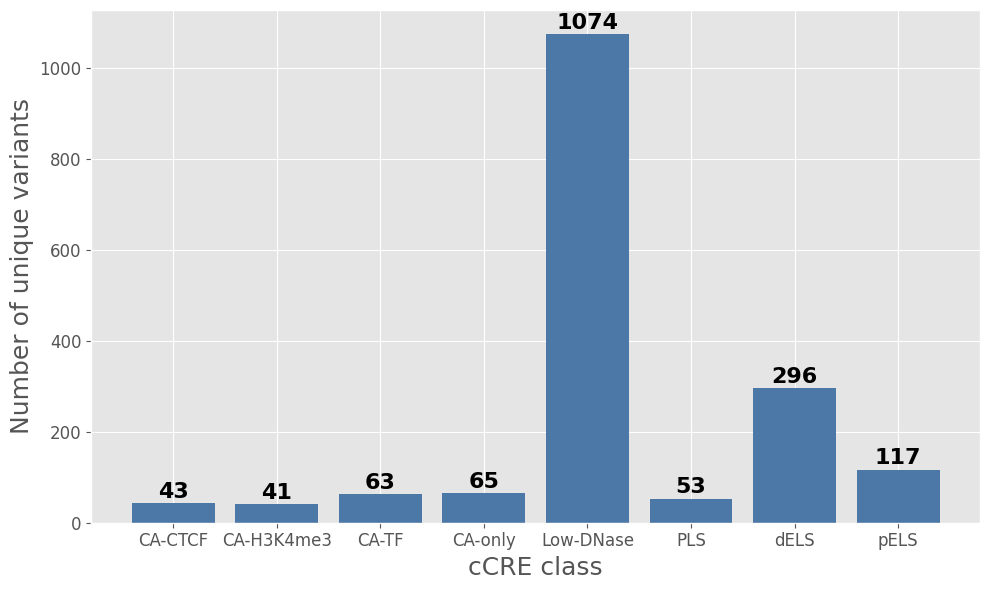

In [71]:
plt.style.use("ggplot")

fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.bar(
    counts["cCRE_CLASS"],
    counts["Total"],
    color="#4C78A8"
)

ax.set_xlabel("cCRE class", fontsize=18)
ax.set_ylabel("Number of unique variants", fontsize=18)
ax.tick_params(axis="x", labelsize=12) #rotation=45
ax.tick_params(axis="y", labelsize=12) #rotation=45

# Variant count labels inside bars
for bar, count in zip(bars, counts["Total"]):
    ax.text(
        (bar.get_x() + bar.get_width() / 2) ,
        count + 25,
        f"{count}",
        va="center",
        ha="center",
        fontsize=16,
        fontweight="bold",
        #color="white"
    )


plt.tight_layout()
plt.show()

In [11]:
ccres_variants2 = ccres_variants2[
    ~ccres_variants2["cCRE_CLASS"].str.contains(
        r"Low-DNase|CA-only",
        na=False
    )
].copy()
ccres_variants2["ID"].nunique()

554

In [12]:
counts = (
    ccres_variants2.groupby("cCRE_CLASS")["ID"]
      .nunique()
      .reset_index(name="unique_IDs")
)
counts

,cCRE_CLASS,unique_IDs
0,CA-CTCF,43
1,CA-H3K4me3,41
2,CA-TF,63
3,PLS,53
4,dELS,296
5,pELS,117


### Number of variants in an SCN associated cCREs

In [3]:
scn_variants = pd.read_csv("/archive/emedgene_data/variant_analysis/output_original/postprocessing/panel_involved_variants.tsv", sep="\t")

In [4]:
scn_variants["ID"].nunique()

145

In [ ]:
def remove_ccre_classes(row):
    classes = [x.strip() for x in str(row["cCRE_CLASS"]).split(",")]
    ids = [x.strip() for x in str(row["cCRE_ID"]).split(",")]

    keep = [
        i for i, cls in enumerate(classes)
        if cls not in ["Low-DNase", "CA-only"]
    ]

    row["cCRE_CLASS"] = ",".join(classes[i] for i in keep)
    row["cCRE_ID"] = ",".join(ids[i] for i in keep)

    return row


scn_variants = scn_variants.apply(remove_ccre_classes, axis=1)
scn_variants = scn_variants.dropna(subset=["cCRE_ID"]).copy()

scn_variants = scn_variants[
    scn_variants["cCRE_ID"].str.strip().ne("")
].copy()

In [39]:
scn_variants["ID"].nunique()

83

In [41]:
panel_cols = [
    "PANEL_SUPP_HPO",
    "PANEL_SUPP_Nedrex_Diamond",
    "PANEL_SUPP_Nedrex_Domino",
    "PANEL_SUPP_String_Diamond",
    "PANEL_SUPP_String_Domino",
    "PANEL_SUPP"
]

df = scn_variants.copy()

df["cCRE_CLASS"] = df["cCRE_CLASS"].str.split(",")
df = df.explode("cCRE_CLASS")
df["cCRE_CLASS"] = df["cCRE_CLASS"].str.strip()

counts_scn = (
    df.groupby("cCRE_CLASS")
    .apply(
        lambda g: pd.Series({
            "total": g["ID"].nunique(),
            **{
                col: g.loc[
                    g[col].notna() & g[col].ne("[]"),
                    "ID"
                ].nunique()
                for col in panel_cols
            }
        })
    )
    .reset_index()
)
counts_scn

/tmp/ipykernel_1446639/2148679094.py:18: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(


,cCRE_CLASS,total,PANEL_SUPP_HPO,PANEL_SUPP_Nedrex_Diamond,PANEL_SUPP_Nedrex_Domino,PANEL_SUPP_String_Diamond,PANEL_SUPP_String_Domino,PANEL_SUPP
0,CA-CTCF,2,2,0,0,0,0,0
1,CA-H3K4me3,4,1,0,1,1,1,0
2,CA-TF,5,0,2,0,1,1,1
3,PLS,20,2,8,1,10,3,3
4,dELS,41,7,16,0,16,2,7
5,pELS,26,5,8,2,12,0,5


In [42]:
df_all = ccres_variants2.copy()

df_all["cCRE_CLASS"] = df_all["cCRE_CLASS"].str.split(",")
df_all = df_all.explode("cCRE_CLASS")
df_all["cCRE_CLASS"] = df_all["cCRE_CLASS"].str.strip()

counts = (
    df_all.groupby("cCRE_CLASS")["ID"]
    .nunique()
    .reset_index(name="Total")
)
counts

,cCRE_CLASS,Total
0,CA-CTCF,43
1,CA-H3K4me3,41
2,CA-TF,63
3,PLS,53
4,dELS,296
5,pELS,117


In [43]:
plot_df = counts.merge(
    counts_scn[["cCRE_CLASS"] + panel_cols],
    on="cCRE_CLASS",
    how="left"
)

In [20]:
plot_df

,cCRE_CLASS,Total,PANEL_SUPP_HPO,PANEL_SUPP_Nedrex_Diamond,PANEL_SUPP_Nedrex_Domino,PANEL_SUPP_String_Diamond,PANEL_SUPP_String_Domino,PANEL_SUPP
0,CA-CTCF,43,1,0,0,0,0,0
1,CA-H3K4me3,41,0,0,0,1,1,0
2,CA-TF,63,0,2,0,0,1,1
3,PLS,53,1,5,1,8,3,2
4,dELS,296,6,12,0,12,2,5
5,pELS,117,4,5,2,9,0,3


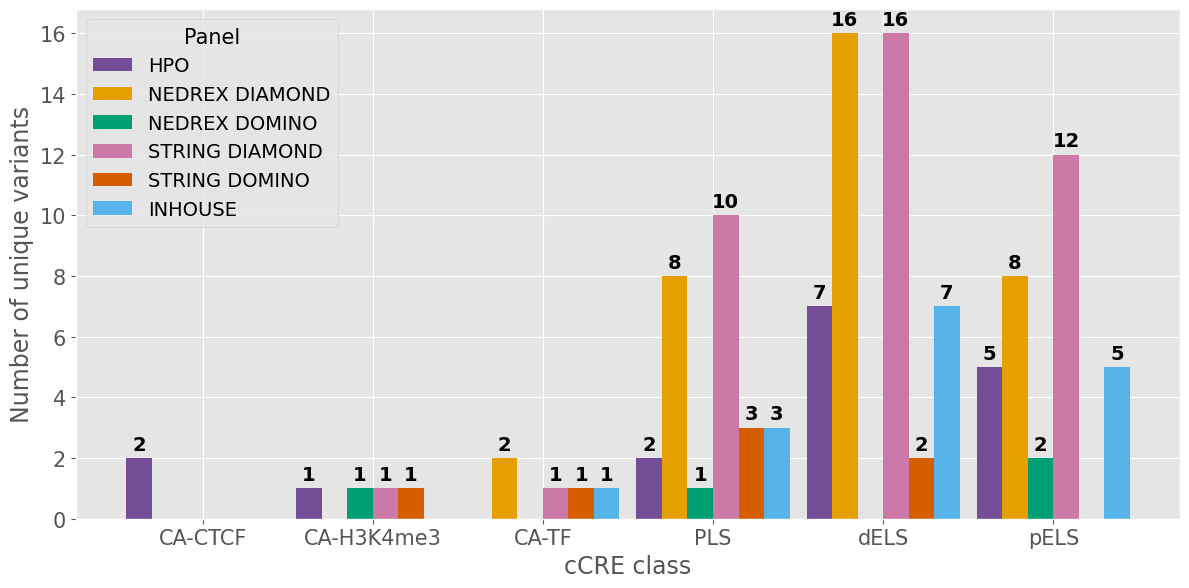

In [75]:
plot_panels = [
    "PANEL_SUPP_HPO",
    "PANEL_SUPP_Nedrex_Diamond",
    "PANEL_SUPP_Nedrex_Domino",
    "PANEL_SUPP_String_Diamond",
    "PANEL_SUPP_String_Domino",
    "PANEL_SUPP_INHOUSE",
]

colors = [
    "#734D95",  # blue
    "#E69F00",  # orange
    "#009E73",  # green
    "#CC79A7",  # purple
    "#D55E00",  # vermillion
    "#56B4E9"   # sky blue
]

x = np.arange(len(plot_df))
width = 0.15

plt.style.use("ggplot")

fig, ax = plt.subplots(figsize=(12, 6))

for i, (panel, color) in enumerate(zip(plot_panels, colors)):

    
    if panel == "PANEL_SUPP_INHOUSE":
        panel_name = "PANEL_SUPP"
    else:
        panel_name = panel

    bars = ax.bar(
            x + (i - (len(plot_panels) - 1) / 2) * width,
            plot_df[panel_name],
            width,
            label=panel.replace("PANEL_SUPP_", "").replace("_", " ").upper(),
            color=color
        )

    # Add labels only for non-zero bars
    labels = [
        f"{int(v)}" if v != 0 else ""
        for v in plot_df[panel_name]
    ]

    ax.bar_label(
        bars,
        labels=labels,
        padding=3,
        fontsize=14,
        fontweight="bold",
    )

ax.set_xlabel("cCRE class", fontsize=17)
ax.set_ylabel("Number of unique variants", fontsize=17)

ax.tick_params(
    axis="both",
    labelsize=15
)

ax.set_xticks(x)
ax.set_xticklabels(
    plot_df["cCRE_CLASS"],
    #rotation=45,
    ha="center"
)

ax.legend(
    title="Panel",
    fontsize=14,
    title_fontsize=15
)


plt.tight_layout()
plt.show()

### Number of variants within a SCN gene region

In [11]:
n_panel

array(['12_DRAGEN:DEL:146409:0:1:0:0:0', '4_DRAGEN:DEL:154371:0:1:0:0:0',
       '66_DRAGEN:INS:115486:0:0:0:4:0', '12_DRAGEN:INS:18783:0:0:0:17:0',
       '112_DRAGEN:INS:68938:0:0:0:8:0', '6_DRAGEN:DEL:31741:1:2:0:0:0',
       '100_DRAGEN:INS:56897:0:0:0:2:0',
       '113_DRAGEN:INS:302177:0:0:1:9:0',
       '128_DRAGEN:DEL:79964:0:0:0:0:0',
       '120_DRAGEN:INS:909702:0:0:0:6:0',
       '107_DRAGEN:DEL:103926:0:1:1:0:0', '62_MantaINS:103957:0:0:0:3:0',
       '15_DRAGEN:INS:196226:0:0:0:6:0',
       '129_DRAGEN:INS:132983:0:0:0:7:0',
       '100_DRAGEN:DEL:128340:0:0:0:0:0',
       '66_DRAGEN:INS:169644:0:0:0:0:0', '56_DRAGEN:DEL:159427:0:0:0:2:0',
       '120_DRAGEN:INS:859585:0:0:0:3:0',
       '10_DRAGEN:INS:42734:0:0:0:10:0'], dtype=object)

In [13]:
# panel
n_panel = scn_variants[scn_variants["PANEL_SUPP"] != "[]"]["ID"].unique()
n_hpo = scn_variants[scn_variants["PANEL_SUPP_HPO"] != "[]"]["ID"].unique()
n_nedrex_diamond = scn_variants[scn_variants["PANEL_SUPP_Nedrex_Diamond"] != "[]"]["ID"].unique()
n_nedrex_domino = scn_variants[scn_variants["PANEL_SUPP_Nedrex_Domino"] != "[]"]["ID"].unique()
n_string_diamond = scn_variants[scn_variants["PANEL_SUPP_String_Diamond"] != "[]"]["ID"].unique()
n_string_domino = scn_variants[scn_variants["PANEL_SUPP_String_Domino"] != "[]"]["ID"].unique()


print("\ncCREs annotated Variant support by gene set")
print("-" * 40)
print(f"{'Panel':<18} {len(n_panel):>8,}")
print(f"{'HPO':<18} {len(n_hpo):>8,}")
print(f"{'NeDReX Diamond':<18} {len(n_nedrex_diamond):>8,}")
print(f"{'NeDReX Domino':<18} {len(n_nedrex_domino):>8,}")
print(f"{'STRING Diamond':<18} {len(n_string_diamond):>8,}")
print(f"{'STRING Domino':<18} {len(n_string_domino):>8,}")
print("-" * 40)



cCREs annotated Variant support by gene set
----------------------------------------
Panel                    19
HPO                      26
NeDReX Diamond           44
NeDReX Domino            12
STRING Diamond           55
STRING Domino            12
----------------------------------------


### Get variants within both ccres and genes

In [73]:
base_dir = Path("/archive/emedgene_data/variant_analysis/output/gene_region")
files = list(base_dir.rglob("gene_region_summary.bed"))

gene_regions = []

for file in files:
    df = pd.read_csv(file, sep="\t")
    df["SUBDIR"] = file.parent.name
    gene_regions.append(df)

gene_regions = pd.concat(gene_regions, ignore_index=True)

# Keep only variants whose ID occurs in scn_variants
overlaps = gene_regions[
    gene_regions["ID"].isin(scn_variants["ID"])
].copy()

overlaps = overlaps.merge(
    scn_variants[["ID", "cCRE_ID", "cCRE_CLASS", "GENE_NAME"]],
    on="ID",
    how="left"
)

In [ ]:
overlaps

### Overall number of variants with eQTL support found across all variants within cCREs

In [47]:
n_eqtl = ccres_variants2[ccres_variants2["eQTL_SUPP"]]["ID"].nunique()
n_eqtl

17

### Number of Variants with CNV support across all disease relevant variants

In [40]:
SV_COL=[
    "CHROM", 
    "AVG_START",
    "AVG_END", 
    "GT", 
    "ID",
    "SVTYPE",
    "AVG_LEN", 
    "SAMPLES_HET",
    "SAMPLES_HOM", 
    "CNV_SUPP"
]
all_sv = pd.read_csv("/archive/emedgene_data/variant_analysis/output_final/cnv_support/filtered_sv.bed", sep="\t", header=None, names=SV_COL)


In [41]:
n_cnv = all_sv[all_sv["CNV_SUPP"]]["ID"].nunique()
n_cnv

11685

In [48]:
n_cnv_ccres_variants = ccres_variants2[ccres_variants2["CNV_SUPP"]]["ID"].nunique()
n_cnv_ccres_variants

517